# Parallel CNN-LSTM Model with Bayesian Optimization

This notebook implements a parallel architecture where CNN and LSTM branches process the same input simultaneously, with comprehensive Bayesian optimization and robustness features.

In [1]:
import os
import h5py
import time
import matplotlib
import numpy as np
import pandas as pd
import seaborn as sns
from pandas import DataFrame
import matplotlib.pyplot as plt
from matplotlib import gridspec
import os
import h5py
import time
import matplotlib
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd
import seaborn as sns
from pandas import DataFrame
import matplotlib.pyplot as plt
from matplotlib import gridspec
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.metrics import classification_report
from sklearn.pipeline import Pipeline
%matplotlib inline
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.metrics import classification_report
from sklearn.pipeline import Pipeline
import keras
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import Dropout
from deap import algorithms, base, creator, tools
import tensorflow as tf
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Masking, TimeDistributed
from keras.models import Sequential
from keras.layers import Dense, Conv1D
from keras.layers import Dropout, Input
from keras import initializers
from keras.layers import MaxPooling1D, GlobalMaxPooling1D, GlobalAveragePooling1D
from keras.models import Model
from keras.layers import TimeDistributed, Flatten, Concatenate
from keras.layers import Dense, Activation, Dropout
from keras.callbacks import EarlyStopping
from keras.callbacks import ModelCheckpoint
import keras_tuner as kt
from datetime import datetime
%matplotlib inline

In [2]:
filename = 'N-CMAPSS_DS05.h5'

In [3]:
# Time tracking, Operation time (min):  0.003
t = time.process_time()  

# Load data
with h5py.File(filename, 'r') as hdf:
        # Development set
        W_dev = np.array(hdf.get('W_dev'))             # W
        X_s_dev = np.array(hdf.get('X_s_dev'))         # X_s
        X_v_dev = np.array(hdf.get('X_v_dev'))         # X_v
        T_dev = np.array(hdf.get('T_dev'))             # T
        Y_dev = np.array(hdf.get('Y_dev'))             # RUL  
        A_dev = np.array(hdf.get('A_dev'))             # Auxiliary

        # Test set
        W_test = np.array(hdf.get('W_test'))           # W
        X_s_test = np.array(hdf.get('X_s_test'))       # X_s
        X_v_test = np.array(hdf.get('X_v_test'))       # X_v
        T_test = np.array(hdf.get('T_test'))           # T
        Y_test = np.array(hdf.get('Y_test'))           # RUL  
        A_test = np.array(hdf.get('A_test'))           # Auxiliary
        
        # Varnams
        W_var = np.array(hdf.get('W_var'))
        X_s_var = np.array(hdf.get('X_s_var'))  
        X_v_var = np.array(hdf.get('X_v_var')) 
        T_var = np.array(hdf.get('T_var'))
        A_var = np.array(hdf.get('A_var'))
        
        # from np.array to list dtype U4/U5
        W_var = list(np.array(W_var, dtype='U20'))
        X_s_var = list(np.array(X_s_var, dtype='U20'))  
        X_v_var = list(np.array(X_v_var, dtype='U20')) 
        T_var = list(np.array(T_var, dtype='U20'))
        A_var = list(np.array(A_var, dtype='U20'))
                          
W = np.concatenate((W_dev, W_test), axis=0)  
X_s = np.concatenate((X_s_dev, X_s_test), axis=0)
X_v = np.concatenate((X_v_dev, X_v_test), axis=0)
T = np.concatenate((T_dev, T_test), axis=0)
Y = np.concatenate((Y_dev, Y_test), axis=0) 
A = np.concatenate((A_dev, A_test), axis=0) 
    
print('')
print("Operation time (min): " , (time.process_time()-t)/60)
print('')
print ("W shape: " + str(W.shape))
print ("X_s shape: " + str(X_s.shape))
print ("X_v shape: " + str(X_v.shape))
print ("Y shape: " + str(Y.shape))
print ("T shape: " + str(T.shape))
print ("A shape: " + str(A.shape))


Operation time (min):  0.061197916666666664

W shape: (6912652, 4)
X_s shape: (6912652, 14)
X_v shape: (6912652, 14)
Y shape: (6912652, 1)
T shape: (6912652, 10)
A shape: (6912652, 4)


In [4]:
W = np.concatenate((W_dev, W_test), axis=0)  
X_s = np.concatenate((X_s_dev, X_s_test), axis=0)
Y = np.concatenate((Y_dev, Y_test), axis=0)
A = np.concatenate((A_dev, A_test), axis=0) 

X = np.concatenate((W, X_s, A, Y), axis=1)
Y=  np.concatenate((A, Y), axis=1)
Y = DataFrame(data=Y, columns=A_var+['Y'])
X = DataFrame(data=X, columns=W_var+X_s_var+A_var+['Y'])

In [5]:
Y.describe()

,unit,cycle,Fc,hs,Y
count,6.912652e+06,6.912652e+06,6.912652e+06,6.912652e+06,6.912652e+06
mean,5.239374e+00,4.002810e+01,2.226115e+00,2.958030e-01,3.900481e+01
std,2.904136e+00,2.368351e+01,8.078304e-01,4.564029e-01,2.376696e+01
min,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00
25%,2.000000e+00,2.000000e+01,2.000000e+00,0.000000e+00,1.900000e+01
50%,6.000000e+00,3.900000e+01,2.000000e+00,0.000000e+00,3.800000e+01
75%,8.000000e+00,5.900000e+01,3.000000e+00,1.000000e+00,5.800000e+01
max,1.000000e+01,1.000000e+02,3.000000e+00,1.000000e+00,9.900000e+01


In [6]:
Y.drop("cycle",axis=1,inplace=True)
Y.drop("Fc",axis=1,inplace=True)
Y.drop("hs",axis=1,inplace=True)
Y.describe()

,unit,Y
count,6.912652e+06,6.912652e+06
mean,5.239374e+00,3.900481e+01
std,2.904136e+00,2.376696e+01
min,1.000000e+00,0.000000e+00
25%,2.000000e+00,1.900000e+01
50%,6.000000e+00,3.800000e+01
75%,8.000000e+00,5.800000e+01
max,1.000000e+01,9.900000e+01


In [7]:
X.drop("cycle",axis=1,inplace=True)
X.drop("Fc",axis=1,inplace=True)
X.drop("hs",axis=1,inplace=True)
X.drop("alt",axis=1,inplace=True)
X.describe()

,Mach,TRA,T2,T24,T30,T48,T50,P15,P2,P21,P24,Ps30,P40,P50,Nf,Nc,Wf,unit,Y
count,6.912652e+06,6.912652e+06,6.912652e+06,6.912652e+06,6.912652e+06,6.912652e+06,6.912652e+06,6.912652e+06,6.912652e+06,6.912652e+06,6.912652e+06,6.912652e+06,6.912652e+06,6.912652e+06,6.912652e+06,6.912652e+06,6.912652e+06,6.912652e+06,6.912652e+06
mean,5.319760e-01,5.996256e+01,4.909356e+02,5.699286e+02,1.334474e+03,1.638378e+03,1.129818e+03,1.304474e+01,1.019378e+01,1.324339e+01,1.606218e+01,2.379398e+02,2.422144e+02,1.019697e+01,1.953364e+03,8.248141e+03,2.548930e+00,5.239374e+00,3.900481e+01
std,1.208898e-01,1.834395e+01,1.985279e+01,2.112542e+01,6.869315e+01,1.239105e+02,6.251462e+01,2.883393e+00,2.421477e+00,2.927303e+00,3.450926e+00,5.919650e+01,6.003612e+01,2.758136e+00,1.873247e+02,2.277543e+02,7.877672e-01,2.904136e+00,2.376696e+01
min,3.150000e-04,2.355452e+01,4.369255e+02,4.998511e+02,1.091806e+03,1.095354e+03,7.923581e+02,6.700688e+00,5.285918e+00,6.802729e+00,8.186232e+00,9.248497e+01,9.466065e+01,4.635623e+00,1.471000e+03,7.429764e+03,5.963687e-01,1.000000e+00,0.000000e+00
25%,4.393620e-01,4.631803e+01,4.741667e+02,5.546204e+02,1.287931e+03,1.552724e+03,1.085702e+03,1.049740e+01,7.972020e+00,1.065726e+01,1.319101e+01,1.929589e+02,1.965787e+02,7.665725e+00,1.835894e+03,8.094517e+03,1.980253e+00,2.000000e+00,1.900000e+01
50%,5.371380e-01,6.257768e+01,4.960515e+02,5.678197e+02,1.329839e+03,1.647608e+03,1.120127e+03,1.338949e+01,1.060965e+01,1.359339e+01,1.617596e+01,2.256779e+02,2.301263e+02,1.051082e+01,1.997333e+03,8.237001e+03,2.340848e+00,6.000000e+00,3.800000e+01
75%,6.330240e-01,7.664008e+01,5.072438e+02,5.838195e+02,1.373982e+03,1.711727e+03,1.165307e+03,1.528072e+01,1.209400e+01,1.551342e+01,1.847904e+01,2.724938e+02,2.773639e+02,1.232305e+01,2.112084e+03,8.383625e+03,2.948869e+00,8.000000e+00,5.800000e+01
max,7.492590e-01,8.876890e+01,5.343834e+02,6.341967e+02,1.540888e+03,1.993206e+03,1.356282e+03,2.044899e+01,1.568410e+01,2.076040e+01,2.643985e+01,4.485121e+02,4.553945e+02,1.672457e+01,2.285550e+03,8.921408e+03,5.607345e+00,1.000000e+01,9.900000e+01


In [8]:
df_A = DataFrame(data=A, columns=A_var)
df_A.describe()

,unit,cycle,Fc,hs
count,6.912652e+06,6.912652e+06,6.912652e+06,6.912652e+06
mean,5.239374e+00,4.002810e+01,2.226115e+00,2.958030e-01
std,2.904136e+00,2.368351e+01,8.078304e-01,4.564029e-01
min,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00
25%,2.000000e+00,2.000000e+01,2.000000e+00,0.000000e+00
50%,6.000000e+00,3.900000e+01,2.000000e+00,0.000000e+00
75%,8.000000e+00,5.900000e+01,3.000000e+00,1.000000e+00
max,1.000000e+01,1.000000e+02,3.000000e+00,1.000000e+00


In [9]:
print('Engine units in df: ', np.unique(X['unit']))
print('Engine units in df: ', np.unique(Y['unit']))

Engine units in df:  [ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10.]
Engine units in df:  [ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10.]


In [10]:
X_train= X.loc[(X.unit == 1) | (X.unit == 3) | (X.unit == 5) | (X.unit == 6) | (X.unit == 7) | (X.unit == 9) | (X.unit == 10) ]
Y_train=Y.loc[(Y.unit == 1) | (Y.unit == 3) | (Y.unit == 5) |  (Y.unit == 6) | (Y.unit == 7) | (Y.unit == 9) | (Y.unit == 10) ]
X_test=X.loc[(X.unit == 2) | (X.unit == 4) | (X.unit == 8) ]
Y_test=Y.loc[(Y.unit == 2) | (Y.unit == 4) | (Y.unit == 8) ]

In [11]:
print('Engine units in df: ', np.unique(X_train['unit']))
print('Engine units in df: ', np.unique(Y_train['unit']))
print('Engine units in df: ', np.unique(X_test['unit']))
print('Engine units in df: ', np.unique(Y_test['unit']))
print("X_train size is ",X_train.shape)
print("X_test size is ",X_test.shape)
print("y_train size is ",Y_train.shape)
print("y_test size is ",Y_test.shape)

Engine units in df:  [ 1.  3.  5.  6.  7.  9. 10.]
Engine units in df:  [ 1.  3.  5.  6.  7.  9. 10.]
Engine units in df:  [2. 4. 8.]
Engine units in df:  [2. 4. 8.]
X_train size is  (4900033, 19)
X_test size is  (2012619, 19)
y_train size is  (4900033, 2)
y_test size is  (2012619, 2)


In [12]:
X_train.drop("unit",axis=1,inplace=True)
X_test.drop("unit",axis=1,inplace=True)
X_train.drop("Y",axis=1,inplace=True)
X_test.drop("Y",axis=1,inplace=True)
Y_train.drop("unit",axis=1,inplace=True)
Y_test.drop("unit",axis=1,inplace=True)
print("X_train size is ",X_train.shape)
print("X_test size is ",X_test.shape)
print("y_train size is ",Y_train.shape)
print("y_test size is ",Y_test.shape)

C:\Users\AUC\AppData\Local\Temp\ipykernel_21440\816249269.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train.drop("unit",axis=1,inplace=True)
C:\Users\AUC\AppData\Local\Temp\ipykernel_21440\816249269.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test.drop("unit",axis=1,inplace=True)
C:\Users\AUC\AppData\Local\Temp\ipykernel_21440\816249269.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train.drop("Y",axis=1,inpl

X_train size is  (4900033, 17)
X_test size is  (2012619, 17)
y_train size is  (4900033, 1)
y_test size is  (2012619, 1)


C:\Users\AUC\AppData\Local\Temp\ipykernel_21440\816249269.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Y_test.drop("unit",axis=1,inplace=True)


In [13]:
# Data normalization
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Reshape for CNN/LSTM input (samples, timesteps, features)
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

print("X_train shape after reshaping:", X_train.shape)
print("X_test shape after reshaping:", X_test.shape)

X_train shape after reshaping: (4900033, 17, 1)
X_test shape after reshaping: (2012619, 17, 1)


In [14]:
# ========== FIX FOR DATA LEAKAGE ==========
# Create validation set from training data to avoid leakage
# The test set will remain completely isolated until final evaluation

print("\n" + "="*70)
print("CREATING VALIDATION SET FROM TRAINING DATA")
print("="*70)

# Split training data into train and validation (80-20 split)
from sklearn.model_selection import train_test_split

X_train_split, X_val, Y_train_split, Y_val = train_test_split(
    X_train, Y_train,
    test_size=0.2,
    random_state=42
)

print(f"\nOriginal training set size: {X_train.shape}")
print(f"New training set size: {X_train_split.shape}")
print(f"Validation set size: {X_val.shape}")
print(f"Test set size (ISOLATED): {X_test.shape}")

print(f"\nOriginal Y_train size: {Y_train.shape}")
print(f"New Y_train_split size: {Y_train_split.shape}")
print(f"Y_val size: {Y_val.shape}")
print(f"Y_test size (ISOLATED): {Y_test.shape}")

print("\n" + "="*70)
print("DATA SPLIT SUMMARY:")
print("="*70)
print("✓ Training set: Used for model training")
print("✓ Validation set: Used for hyperparameter tuning (Bayesian Optimization)")
print("✓ Test set: COMPLETELY ISOLATED - Used only for final evaluation")
print("="*70 + "\n")


CREATING VALIDATION SET FROM TRAINING DATA

Original training set size: (4900033, 17, 1)
New training set size: (3920026, 17, 1)
Validation set size: (980007, 17, 1)
Test set size (ISOLATED): (2012619, 17, 1)

Original Y_train size: (4900033, 1)
New Y_train_split size: (3920026, 1)
Y_val size: (980007, 1)
Y_test size (ISOLATED): (2012619, 1)

DATA SPLIT SUMMARY:
✓ Training set: Used for model training
✓ Validation set: Used for hyperparameter tuning (Bayesian Optimization)
✓ Test set: COMPLETELY ISOLATED - Used only for final evaluation



## Parallel CNN-LSTM Model with Bayesian Optimization

This section implements a parallel architecture where CNN and LSTM branches process the same input simultaneously, then their outputs are concatenated and fed to dense layers.

In [15]:
def create_parallel_model(hp):
    """
    Creates a parallel CNN-LSTM model with tunable hyperparameters.
    CNN and LSTM branches work on the same input simultaneously.
    """
    # Input layer
    input_layer = Input(shape=(X_train.shape[1], 1))
    
    # ==================== CNN BRANCH ====================
    cnn_branch = input_layer
    
    # Tune the number of CNN layers
    num_cnn_layers = hp.Int("num_cnn_layers", 1, 4)
    
    for i in range(num_cnn_layers):
        cnn_branch = Conv1D(
            filters=hp.Int(f"cnn_{i}_filters", min_value=32, max_value=128, step=16),
            kernel_size=hp.Int(f"cnn_{i}_kernel", min_value=3, max_value=7, step=2),
            activation="relu",
            padding="same"  # Use 'same' padding to maintain sequence length
        )(cnn_branch)
        
        # Add dropout after each CNN layer
        cnn_branch = Dropout(rate=hp.Float(f"cnn_{i}_dropout", min_value=0.0, max_value=0.3, step=0.1))(cnn_branch)
        
        # Only add pooling for the first few layers to avoid dimension issues
        if i < 2:  # Only pool in first 2 layers
            cnn_branch = MaxPooling1D(pool_size=2, padding="same")(cnn_branch)
    
    # Global pooling for CNN branch
    cnn_pooling_type = hp.Choice("cnn_pooling", ["max", "avg"])
    if cnn_pooling_type == "max":
        cnn_output = GlobalMaxPooling1D()(cnn_branch)
    else:
        cnn_output = GlobalAveragePooling1D()(cnn_branch)
    
    # ==================== LSTM BRANCH ====================
    lstm_branch = input_layer
    
    # Tune the number of LSTM layers
    num_lstm_layers = hp.Int("num_lstm_layers", 1, 3)
    
    for i in range(num_lstm_layers):
        return_sequences = True if i < num_lstm_layers - 1 else False
        
        lstm_branch = LSTM(
            units=hp.Int(f"lstm_{i}_units", min_value=32, max_value=128, step=16),
            return_sequences=return_sequences,
            dropout=hp.Float(f"lstm_{i}_dropout", min_value=0.0, max_value=0.3, step=0.1),
            recurrent_dropout=hp.Float(f"lstm_{i}_recurrent_dropout", min_value=0.0, max_value=0.3, step=0.1)
        )(lstm_branch)
    
    lstm_output = lstm_branch
    
    # ==================== MERGE BRANCHES ====================
    # Concatenate CNN and LSTM outputs
    merged = Concatenate()([cnn_output, lstm_output])
    
    # ==================== DENSE LAYERS ====================
    # Tune the number of dense layers
    num_dense_layers = hp.Int("num_dense_layers", 1, 3)
    
    x = merged
    for i in range(num_dense_layers):
        x = Dense(
            units=hp.Int(f"dense_{i}_units", min_value=32, max_value=256, step=32),
            activation="relu"
        )(x)
        x = Dropout(rate=hp.Float(f"dense_{i}_dropout", min_value=0.0, max_value=0.5, step=0.1))(x)
    
    # Output layer
    output_layer = Dense(1, activation="linear")(x)
    
    # Create the model
    model = Model(inputs=input_layer, outputs=output_layer)
    
    # Compile the model
    optimizer_choice = hp.Choice("optimizer", ["adam", "rmsprop", "sgd"])
    learning_rate = hp.Choice("learning_rate", values=[1e-2, 1e-3, 1e-4, 1e-5])
    
    if optimizer_choice == "adam":
        optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    elif optimizer_choice == "rmsprop":
        optimizer = tf.keras.optimizers.RMSprop(learning_rate=learning_rate)
    else:
        optimizer = tf.keras.optimizers.SGD(learning_rate=learning_rate)
    
    model.compile(
        optimizer=optimizer,
        loss="mean_squared_error",
        metrics=["mean_absolute_error"]
    )
    
    return model

In [16]:
# Initialize Bayesian Optimization tuner with robust checkpointing
import os
from datetime import datetime

# Create a unique project directory with timestamp
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
project_dir = f"parallel_bayesian_optimization_{timestamp}"

# Check if we want to resume from a previous run
resume_project = input("Do you want to resume from a previous run? (y/n): ").lower().strip()

if resume_project == 'y':
    # List available project directories
    available_dirs = [d for d in os.listdir('.') if d.startswith('parallel_bayesian_optimization_') and os.path.isdir(d)]
    if available_dirs:
        print("Available previous runs:")
        for i, dir_name in enumerate(available_dirs):
            print(f"{i+1}. {dir_name}")
        
        choice = int(input("Enter the number of the run to resume: ")) - 1
        if 0 <= choice < len(available_dirs):
            project_dir = available_dirs[choice]
            print(f"Resuming from: {project_dir}")
        else:
            print("Invalid choice. Starting new run.")
    else:
        print("No previous runs found. Starting new run.")

tuner = kt.BayesianOptimization(
    create_parallel_model,
    objective="val_loss",
    max_trials=30,  # Increased trials for comprehensive search
    directory=".",
    project_name=project_dir,
    overwrite=False  # Set to False to enable resumption
)

print(f"Tuner initialized successfully! Project: {project_dir}")
print(f"Trials completed so far: {len(tuner.oracle.trials)}")
print(f"Search space summary:")
tuner.search_space_summary()

Available previous runs:
1. parallel_bayesian_optimization_20251014_195549
2. parallel_bayesian_optimization_20251016_074142
3. parallel_bayesian_optimization_20260207_213135
4. parallel_bayesian_optimization_20260207_213356
Resuming from: parallel_bayesian_optimization_20260207_213356
Reloading Tuner from .\parallel_bayesian_optimization_20260207_213356\tuner0.json
Tuner initialized successfully! Project: parallel_bayesian_optimization_20260207_213356
Trials completed so far: 30
Search space summary:
Search space summary
Default search space size: 33
num_cnn_layers (Int)
{'default': None, 'conditions': [], 'min_value': 1, 'max_value': 4, 'step': 1, 'sampling': 'linear'}
cnn_0_filters (Int)
{'default': None, 'conditions': [], 'min_value': 32, 'max_value': 128, 'step': 16, 'sampling': 'linear'}
cnn_0_kernel (Int)
{'default': None, 'conditions': [], 'min_value': 3, 'max_value': 7, 'step': 2, 'sampling': 'linear'}
cnn_0_dropout (Float)
{'default': 0.0, 'conditions': [], 'min_value': 0.0, 

In [18]:
#Don't run
# 
#  === Skip exactly the NEXT trial once (past trials kept) ===
import types

# Try both keras_tuner and kerastuner (for compatibility)
try:
    from keras_tuner.engine import trial as _kt_trial
except Exception:
    try:
        from kerastuner.engine import trial as _kt_trial
    except Exception:
        _kt_trial = None

_KT_INVALID = getattr(_kt_trial.TrialStatus, "INVALID", "INVALID") if _kt_trial else "INVALID"

# Ensure tuner exists
if "tuner" not in globals():
    raise RuntimeError("Run the tuner creation cell first, then this patch cell.")

# Backup original run_trial
__orig_run_trial = tuner.run_trial
__skip_flag = {"once": True}

def __skip_once_run_trial(self, trial, *args, **kwargs):
    """Skip exactly one pending trial and mark it INVALID."""
    if __skip_flag["once"]:
        tid = getattr(trial, "trial_id", "unknown")
        print(f"[SkipOnce] Skipping trial {tid} and marking it as INVALID.")
        try:
            self.oracle.end_trial(trial_id=trial.trial_id, status=_KT_INVALID)
        except Exception:
            try:
                self.oracle.end_trial(trial_id=trial.trial_id, status="INVALID")
            except Exception:
                print("[SkipOnce] Warning: could not mark trial INVALID properly.")
        # Persist oracle state if possible
        for attr in ("save", "_save_trial"):
            func = getattr(self.oracle, attr, None)
            if callable(func):
                try:
                    func(trial)
                except Exception:
                    pass
        __skip_flag["once"] = False
        return  # Skip execution
    # Continue normal trials afterward
    return __orig_run_trial(trial, *args, **kwargs)

# Apply temporary patch
tuner.run_trial = types.MethodType(__skip_once_run_trial, tuner)
print("✅ Patch active: the NEXT trial will be skipped and marked INVALID. Others continue normally.")


✅ Patch active: the NEXT trial will be skipped and marked INVALID. Others continue normally.


In [18]:
# Start the hyperparameter search with robust error handling
print("Starting Parallel CNN-LSTM Bayesian optimization search...")
print(f"Remaining trials: {tuner.oracle.max_trials - len(tuner.oracle.trials)}")

try:
    # Add callbacks for better monitoring and checkpointing
    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=5,
            restore_best_weights=True
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=3,
            min_lr=1e-7
        )
    ]
    
    tuner.search(
        X_train, Y_train, 
        epochs=20,  # Increased epochs with early stopping
        batch_size=32,
        validation_data=((X_val, Y_val)),
        callbacks=callbacks,
        verbose=1
    )
    
    print("Hyperparameter search completed successfully!")
    
except KeyboardInterrupt:
    print("\nSearch interrupted by user. Progress has been saved.")
    print(f"Completed trials: {len(tuner.oracle.trials)}")
    print("You can resume this search later by running the previous cell and selecting 'y' to resume.")
    
except Exception as e:
    print(f"\nAn error occurred during search: {str(e)}")
    print(f"Completed trials: {len(tuner.oracle.trials)}")
    print("Progress has been saved. You can resume this search later.")





    

print(f"\nTotal completed trials: {len(tuner.oracle.trials)}")
print(f"Project saved in: {project_dir}")

Starting Parallel CNN-LSTM Bayesian optimization search...
Remaining trials: 0
Hyperparameter search completed successfully!

Total completed trials: 30
Project saved in: parallel_bayesian_optimization_20260207_213356


In [19]:
# Check current progress and get results
print(f"Current progress: {len(tuner.oracle.trials)} trials completed out of {tuner.oracle.max_trials}")

if len(tuner.oracle.trials) == 0:
    print("No trials completed yet. Please run the search first.")
else:
    # Display results summary
    tuner.results_summary()
    
    # Get the optimal hyperparameters
    best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

Current progress: 30 trials completed out of 30
Results summary
Results in .\parallel_bayesian_optimization_20260207_213356
Showing 10 best trials
Objective(name="val_loss", direction="min")

Trial 03 summary
Hyperparameters:
num_cnn_layers: 4
cnn_0_filters: 96
cnn_0_kernel: 5
cnn_0_dropout: 0.0
cnn_pooling: avg
num_lstm_layers: 1
lstm_0_units: 80
lstm_0_dropout: 0.0
lstm_0_recurrent_dropout: 0.2
num_dense_layers: 2
dense_0_units: 192
dense_0_dropout: 0.1
optimizer: sgd
learning_rate: 1e-05
cnn_1_filters: 128
cnn_1_kernel: 3
cnn_1_dropout: 0.1
cnn_2_filters: 128
cnn_2_kernel: 7
cnn_2_dropout: 0.2
lstm_1_units: 48
lstm_1_dropout: 0.1
lstm_1_recurrent_dropout: 0.0
lstm_2_units: 80
lstm_2_dropout: 0.2
lstm_2_recurrent_dropout: 0.1
dense_1_units: 96
dense_1_dropout: 0.0
cnn_3_filters: 32
cnn_3_kernel: 3
cnn_3_dropout: 0.0
Score: 47.348121643066406

Trial 01 summary
Hyperparameters:
num_cnn_layers: 3
cnn_0_filters: 128
cnn_0_kernel: 5
cnn_0_dropout: 0.1
cnn_pooling: avg
num_lstm_layers: 3
l

In [20]:
# Display best hyperparameters (only if trials were completed)
if len(tuner.oracle.trials) > 0:
    print("\n" + "="*60)
    print("BEST HYPERPARAMETERS FOR PARALLEL CNN-LSTM MODEL:")
    print("="*60)
    
    # Architecture parameters
    print("\n🏗️  ARCHITECTURE:")
    print(f"   CNN Layers: {best_hps.get('num_cnn_layers')}")
    print(f"   LSTM Layers: {best_hps.get('num_lstm_layers')}")
    print(f"   Dense Layers: {best_hps.get('num_dense_layers')}")
    print(f"   CNN Pooling: {best_hps.get('cnn_pooling')}")
    
    # Optimizer parameters
    print("\n⚙️  OPTIMIZER:")
    print(f"   Type: {best_hps.get('optimizer')}")
    print(f"   Learning Rate: {best_hps.get('learning_rate')}")
    
    # CNN branch details
    print("\n🔍 CNN BRANCH DETAILS:")
    for i in range(best_hps.get('num_cnn_layers')):
        filters = best_hps.get(f'cnn_{i}_filters')
        kernel = best_hps.get(f'cnn_{i}_kernel')
        dropout = best_hps.get(f'cnn_{i}_dropout')
        print(f"   Layer {i+1}: {filters} filters, kernel={kernel}, dropout={dropout}")
    
    # LSTM branch details
    print("\n🔄 LSTM BRANCH DETAILS:")
    for i in range(best_hps.get('num_lstm_layers')):
        units = best_hps.get(f'lstm_{i}_units')
        dropout = best_hps.get(f'lstm_{i}_dropout')
        rec_dropout = best_hps.get(f'lstm_{i}_recurrent_dropout')
        print(f"   Layer {i+1}: {units} units, dropout={dropout}, recurrent_dropout={rec_dropout}")
    
    # Dense layers details
    print("\n🧠 DENSE LAYERS DETAILS:")
    for i in range(best_hps.get('num_dense_layers')):
        units = best_hps.get(f'dense_{i}_units')
        dropout = best_hps.get(f'dense_{i}_dropout')
        print(f"   Layer {i+1}: {units} units, dropout={dropout}")
    
    print("="*60)
else:
    print("No completed trials found. Please run the search first.")


BEST HYPERPARAMETERS FOR PARALLEL CNN-LSTM MODEL:

🏗️  ARCHITECTURE:
   CNN Layers: 4
   LSTM Layers: 1
   Dense Layers: 2
   CNN Pooling: avg

⚙️  OPTIMIZER:
   Type: sgd
   Learning Rate: 1e-05

🔍 CNN BRANCH DETAILS:
   Layer 1: 96 filters, kernel=5, dropout=0.0
   Layer 2: 128 filters, kernel=3, dropout=0.1
   Layer 3: 128 filters, kernel=7, dropout=0.2
   Layer 4: 32 filters, kernel=3, dropout=0.0

🔄 LSTM BRANCH DETAILS:
   Layer 1: 80 units, dropout=0.0, recurrent_dropout=0.2

🧠 DENSE LAYERS DETAILS:
   Layer 1: 192 units, dropout=0.1
   Layer 2: 96 units, dropout=0.0


In [21]:
# Build the model with the optimal hyperparameters (only if trials were completed)
if len(tuner.oracle.trials) > 0:
    model = tuner.hypermodel.build(best_hps)
    print("\n🏆 OPTIMAL PARALLEL CNN-LSTM MODEL ARCHITECTURE:")
    print("="*50)
    model.summary()
    
    # Visualize model architecture
    try:
        tf.keras.utils.plot_model(model, to_file='parallel_model_architecture.png', 
                                show_shapes=True, show_layer_names=True, rankdir='TB')
        print("\n📊 Model architecture diagram saved as 'parallel_model_architecture.png'")
    except:
        print("\n⚠️  Could not generate model diagram (graphviz not installed)")
        
else:
    print("Cannot build model - no completed trials found.")


🏆 OPTIMAL PARALLEL CNN-LSTM MODEL ARCHITECTURE:
Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 17, 1)]      0           []                               
                                                                                                  
 conv1d (Conv1D)                (None, 17, 96)       576         ['input_1[0][0]']                
                                                                                                  
 dropout (Dropout)              (None, 17, 96)       0           ['conv1d[0][0]']                 
                                                                                                  
 max_pooling1d (MaxPooling1D)   (None, 9, 96)        0           ['dropout[0][0]']                
                                             

## Final Model Training & Test Set Evaluation

The Bayesian optimization search is complete (30/30 trials). Now we retrain the best model on the **full training set** (train + validation) and evaluate on the **completely isolated test set** (units 2, 4, 8).

In [22]:
# ========== RETRAIN BEST MODEL ON FULL TRAINING DATA ==========
# During optimization, we used a validation split from training data.
# Now we retrain on ALL training data (X_train, Y_train) using the best
# hyperparameters, and evaluate on the isolated test set (X_test, Y_test).

print("="*70)
print("RETRAINING BEST MODEL ON FULL TRAINING DATA")
print("="*70)

# Build fresh model with the best hyperparameters
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

# Force recurrent_dropout to 0 for all LSTM layers to enable cuDNN acceleration
num_lstm = best_hps.get('num_lstm_layers')
for i in range(num_lstm):
    key = f'lstm_{i}_recurrent_dropout'
    old_val = best_hps.values.get(key, 0.0)
    best_hps.values[key] = 0.0
    if old_val != 0.0:
        print(f'Forced {key}: {old_val} -> 0.0 (for cuDNN acceleration)')

# Check if a checkpoint exists from a previous crashed/interrupted run
checkpoint_path = 'final_retrain_parallel_cnn_lstm_checkpoint.h5'
initial_epoch = 0

if os.path.exists(checkpoint_path):
    print(f"\nFound existing checkpoint: {checkpoint_path}")
    best_model = tf.keras.models.load_model(checkpoint_path)
    # Try to determine which epoch we left off at from the filename or logs
    # We'll ask the user what epoch to resume from
    resume_epoch = input("Enter the last completed epoch number to resume from (or 0 to start fresh): ")
    initial_epoch = int(resume_epoch)
    if initial_epoch > 0:
        print(f"Resuming training from epoch {initial_epoch}")
    else:
        print("Starting fresh training (ignoring checkpoint)")
        best_model = tuner.hypermodel.build(best_hps)
else:
    print("\nNo checkpoint found. Starting fresh training.")
    best_model = tuner.hypermodel.build(best_hps)

print(f"\nTraining data shape: {X_train.shape}")
print(f"Test data shape (ISOLATED): {X_test.shape}")

# Callbacks for final training
final_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=7,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        checkpoint_path,
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    )
]

# Train with resume support
import time as _time
train_start = _time.time()

history = best_model.fit(
    X_train, Y_train,
    epochs=50,
    initial_epoch=initial_epoch,
    batch_size=32,
    validation_split=0.1,
    callbacks=final_callbacks,
    verbose=1
)

train_elapsed = _time.time() - train_start
print(f"\nFinal training complete!")
print(f"Training time: {train_elapsed/60:.2f} minutes ({train_elapsed/3600:.2f} hours)")

RETRAINING BEST MODEL ON FULL TRAINING DATA
Forced lstm_0_recurrent_dropout: 0.2 -> 0.0 (for cuDNN acceleration)

No checkpoint found. Starting fresh training.

Training data shape: (4900033, 17, 1)
Test data shape (ISOLATED): (2012619, 17, 1)
Epoch 1/50
137814/137814 [==============================] - ETA: 0s - loss: 491.7011 - mean_absolute_error: 18.6677
Epoch 1: val_loss improved from inf to 290.71140, saving model to final_retrain_parallel_cnn_lstm_checkpoint.h5
137814/137814 [==============================] - 2483s 18ms/step - loss: 491.7011 - mean_absolute_error: 18.6677 - val_loss: 290.7114 - val_mean_absolute_error: 12.1396 - lr: 1.0000e-05
Epoch 2/50
137814/137814 [==============================] - ETA: 0s - loss: 165.7742 - mean_absolute_error: 9.4492
Epoch 2: val_loss improved from 290.71140 to 118.71419, saving model to final_retrain_parallel_cnn_lstm_checkpoint.h5
137814/137814 [==============================] - 2576s 19ms/step - loss: 165.7742 - mean_absolute_error: 9.44

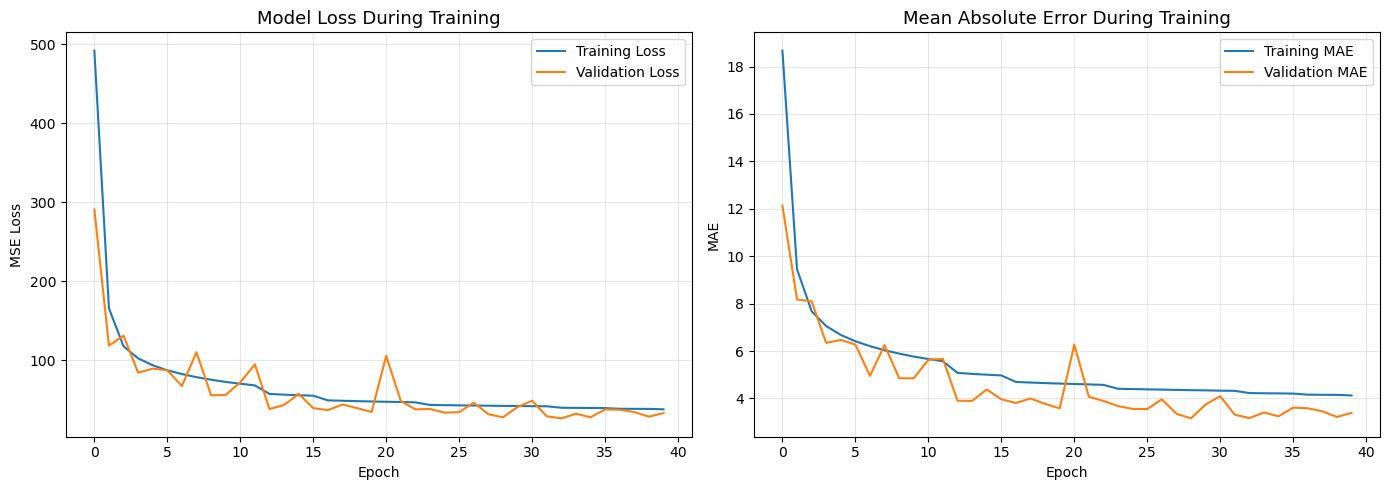

In [23]:
# ========== TRAINING HISTORY PLOTS ==========
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot
axes[0].plot(history.history['loss'], label='Training Loss')
axes[0].plot(history.history['val_loss'], label='Validation Loss')
axes[0].set_title('Model Loss During Training', fontsize=13)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# MAE plot
axes[1].plot(history.history['mean_absolute_error'], label='Training MAE')
axes[1].plot(history.history['val_mean_absolute_error'], label='Validation MAE')
axes[1].set_title('Mean Absolute Error During Training', fontsize=13)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
plt.show()

### Test Set Evaluation (Units 2, 4, 8 — Completely Isolated)

In [24]:
# ========== TEST SET EVALUATION ==========
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import math

print("="*70)
print("TEST SET EVALUATION (Completely Isolated - Units 2, 4, 8)")
print("="*70)

# Predict on the isolated test set
Y_pred = best_model.predict(X_test, batch_size=256, verbose=1)

# Flatten predictions and actuals
y_test_flat = Y_test.values.flatten()
y_pred_flat = Y_pred.flatten()

# Compute metrics
mse  = mean_squared_error(y_test_flat, y_pred_flat)
rmse = math.sqrt(mse)
mae  = mean_absolute_error(y_test_flat, y_pred_flat)
r2   = r2_score(y_test_flat, y_pred_flat)

print(f"\n{'Metric':<30} {'Value':>12}")
print("-" * 44)
print(f"{'Mean Squared Error (MSE)':<30} {mse:>12.4f}")
print(f"{'Root Mean Squared Error (RMSE)':<30} {rmse:>12.4f}")
print(f"{'Mean Absolute Error (MAE)':<30} {mae:>12.4f}")
print(f"{'R-squared (R2)':<30} {r2:>12.4f}")

TEST SET EVALUATION (Completely Isolated - Units 2, 4, 8)
7862/7862 [==============================] - 52s 6ms/step

Metric                                Value
--------------------------------------------
Mean Squared Error (MSE)            46.1410
Root Mean Squared Error (RMSE)       6.7927
Mean Absolute Error (MAE)            5.1498
R-squared (R2)                       0.9280


In [25]:
# ========== NASA SCORING FUNCTION ==========
# The asymmetric scoring function used in PHM/NASA challenges
# penalizes late predictions (overestimating RUL) more heavily than early ones.

def nasa_scoring_function(y_true, y_pred):
    """
    NASA asymmetric scoring function for RUL prediction.
    d < 0 (early prediction): score = exp(-d/13) - 1
    d >= 0 (late prediction):  score = exp(d/10) - 1
    """
    d = y_pred - y_true
    score = np.where(d < 0, np.exp(-d / 13) - 1, np.exp(d / 10) - 1)
    return np.sum(score), np.mean(score)

total_score, avg_score = nasa_scoring_function(y_test_flat, y_pred_flat)

print("NASA Scoring Function (Asymmetric):")
print(f"  Total Score: {total_score:,.2f}")
print(f"  Average Score per sample: {avg_score:.4f}")

NASA Scoring Function (Asymmetric):
  Total Score: 1,357,657.42
  Average Score per sample: 0.6746


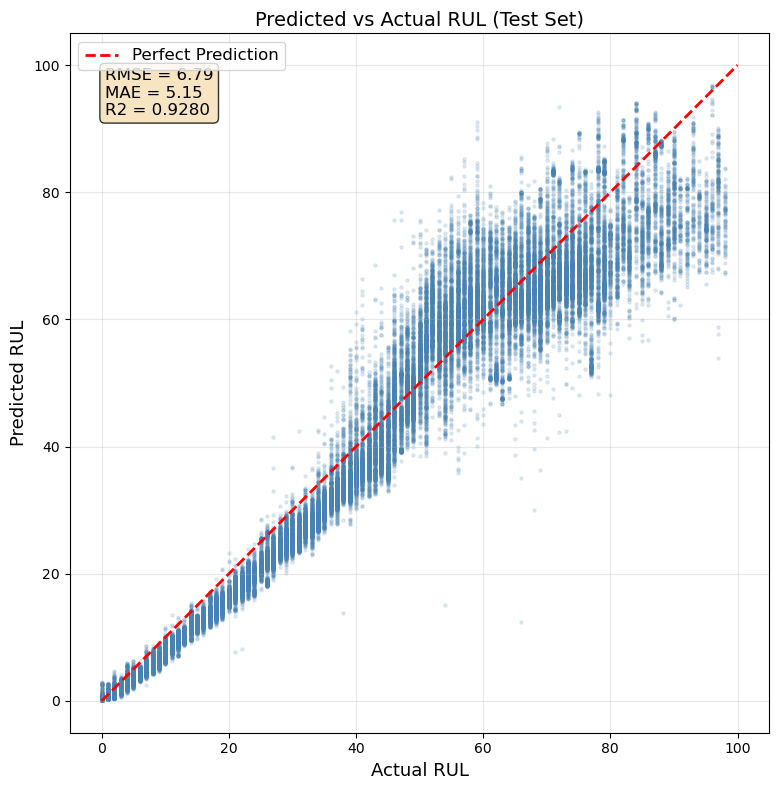

In [26]:
# ========== PREDICTED vs ACTUAL SCATTER PLOT ==========
fig, ax = plt.subplots(figsize=(8, 8))

# Subsample for readability
np.random.seed(42)
sample_idx = np.random.choice(len(y_test_flat), size=min(50000, len(y_test_flat)), replace=False)

ax.scatter(y_test_flat[sample_idx], y_pred_flat[sample_idx], alpha=0.15, s=5, c='steelblue')
ax.plot([0, 100], [0, 100], 'r--', linewidth=2, label='Perfect Prediction')
ax.set_xlabel('Actual RUL', fontsize=13)
ax.set_ylabel('Predicted RUL', fontsize=13)
ax.set_title('Predicted vs Actual RUL (Test Set)', fontsize=14)
ax.legend(fontsize=12)
ax.set_xlim([-5, 105])
ax.set_ylim([-5, 105])
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')

# Add metrics text box
textstr = f'RMSE = {rmse:.2f}\nMAE = {mae:.2f}\nR2 = {r2:.4f}'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=12,
        verticalalignment='top', bbox=props)

plt.tight_layout()
plt.savefig('predicted_vs_actual_RUL.png', dpi=150, bbox_inches='tight')
plt.show()

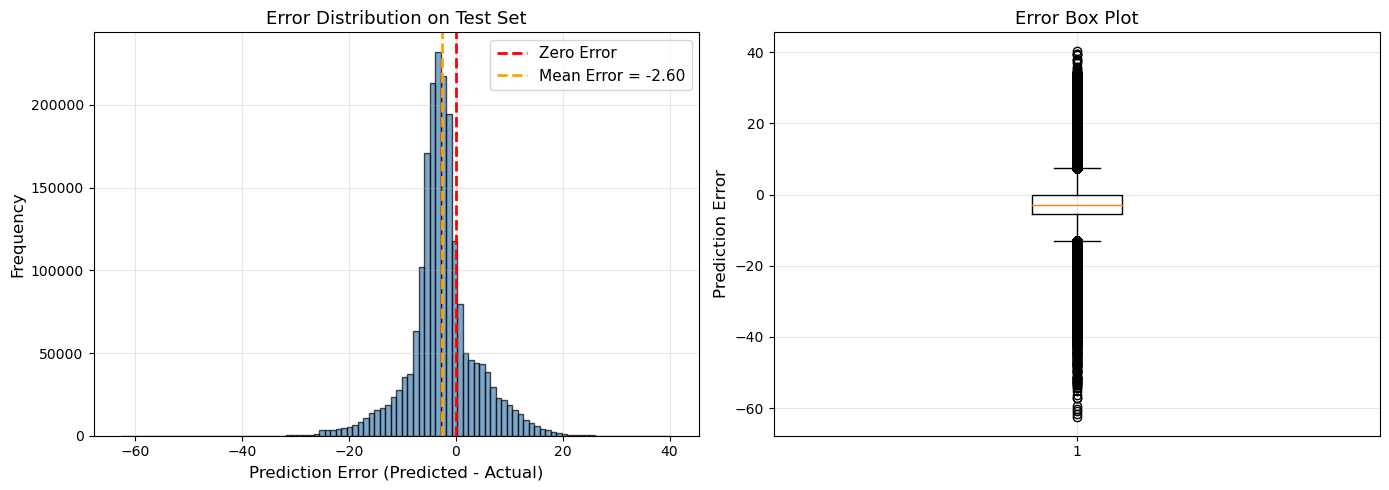

Error Statistics:
  Mean Error:   -2.5994
  Std Error:    6.2757
  Median Error: -2.9315
  Min Error:    -62.6312
  Max Error:    40.4402


In [27]:
# ========== ERROR DISTRIBUTION ==========
errors = y_pred_flat - y_test_flat

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of errors
axes[0].hist(errors, bins=100, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero Error')
axes[0].axvline(x=np.mean(errors), color='orange', linestyle='--', linewidth=2,
                label=f'Mean Error = {np.mean(errors):.2f}')
axes[0].set_xlabel('Prediction Error (Predicted - Actual)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Error Distribution on Test Set', fontsize=13)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Box plot of errors
axes[1].boxplot(errors, vert=True)
axes[1].set_ylabel('Prediction Error', fontsize=12)
axes[1].set_title('Error Box Plot', fontsize=13)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('error_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Error Statistics:")
print(f"  Mean Error:   {np.mean(errors):.4f}")
print(f"  Std Error:    {np.std(errors):.4f}")
print(f"  Median Error: {np.median(errors):.4f}")
print(f"  Min Error:    {np.min(errors):.4f}")
print(f"  Max Error:    {np.max(errors):.4f}")

In [28]:
# ========== PER-UNIT EVALUATION ==========
# Reconstruct unit labels for the test set

df_A = DataFrame(data=A, columns=A_var)
test_units = df_A.loc[(df_A.unit == 2) | (df_A.unit == 4) | (df_A.unit == 8), 'unit'].values

print("="*70)
print("PER-UNIT TEST SET EVALUATION")
print("="*70)
print(f"\n{'Unit':<8} {'MSE':>10} {'RMSE':>10} {'MAE':>10} {'R2':>10} {'NASA Score':>14}")
print("-" * 64)

for unit_id in [2, 4, 8]:
    mask = test_units == unit_id
    y_true_u = y_test_flat[mask]
    y_pred_u = y_pred_flat[mask]
    
    mse_u  = mean_squared_error(y_true_u, y_pred_u)
    rmse_u = math.sqrt(mse_u)
    mae_u  = mean_absolute_error(y_true_u, y_pred_u)
    r2_u   = r2_score(y_true_u, y_pred_u)
    nasa_total_u, _ = nasa_scoring_function(y_true_u, y_pred_u)
    
    print(f"{int(unit_id):<8} {mse_u:>10.2f} {rmse_u:>10.2f} {mae_u:>10.2f} {r2_u:>10.4f} {nasa_total_u:>14,.0f}")

print("-" * 64)
print(f"{'Overall':<8} {mse:>10.2f} {rmse:>10.2f} {mae:>10.2f} {r2:>10.4f} {total_score:>14,.0f}")

PER-UNIT TEST SET EVALUATION

Unit            MSE       RMSE        MAE         R2     NASA Score
----------------------------------------------------------------
2             39.26       6.27       4.95     0.9252        730,150
4             66.45       8.15       6.03     0.9190        374,409
8             43.93       6.63       4.76     0.9382        253,098
----------------------------------------------------------------
Overall       46.14       6.79       5.15     0.9280      1,357,657


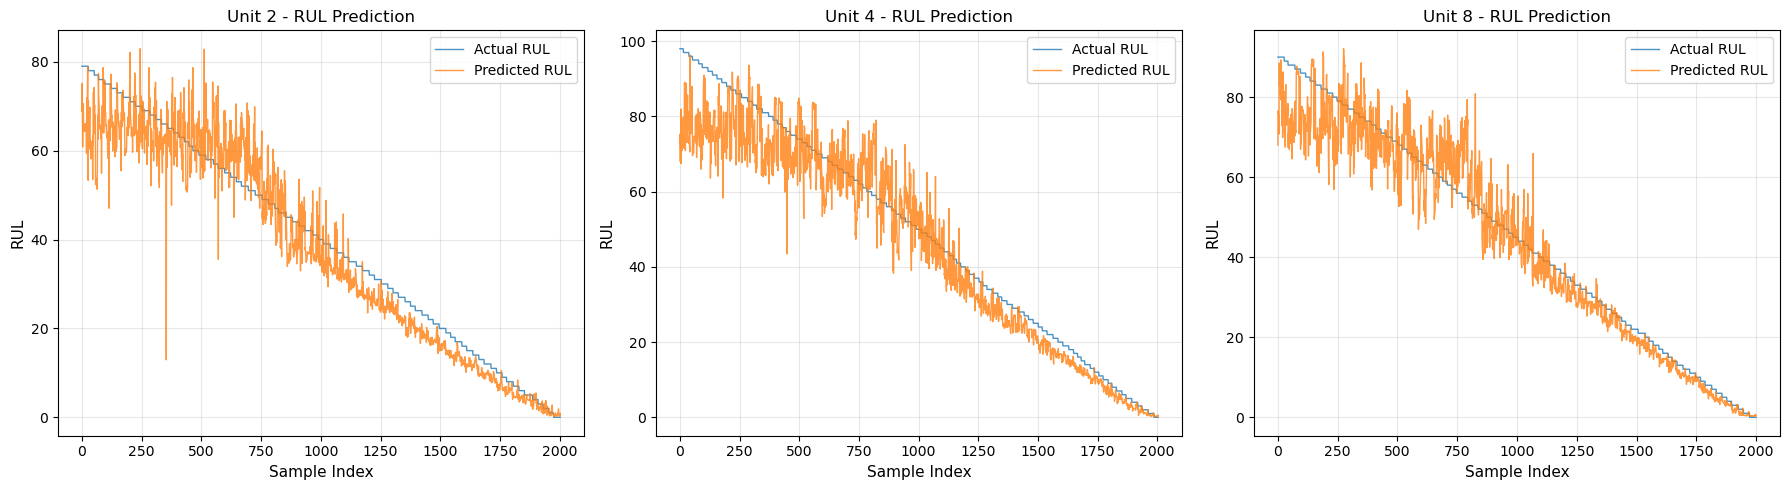

In [29]:
# ========== RUL PREDICTION OVER CYCLES (PER TEST UNIT) ==========
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, unit_id in enumerate([2, 4, 8]):
    mask = test_units == unit_id
    y_true_u = y_test_flat[mask]
    y_pred_u = y_pred_flat[mask]
    
    # Subsample for plot readability
    step = max(1, len(y_true_u) // 2000)
    
    axes[idx].plot(y_true_u[::step], label='Actual RUL', alpha=0.8, linewidth=1)
    axes[idx].plot(y_pred_u[::step], label='Predicted RUL', alpha=0.8, linewidth=1)
    axes[idx].set_xlabel('Sample Index', fontsize=11)
    axes[idx].set_ylabel('RUL', fontsize=11)
    axes[idx].set_title(f'Unit {int(unit_id)} - RUL Prediction', fontsize=12)
    axes[idx].legend(fontsize=10)
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('per_unit_rul_prediction.png', dpi=150, bbox_inches='tight')
plt.show()

In [30]:
# ========== SAVE MODEL & FINAL SUMMARY ==========
best_model.save('final_parallel_cnn_lstm_model.h5')
print("Model saved as 'final_parallel_cnn_lstm_model.h5'")

# Save results to CSV
results_df = pd.DataFrame({
    'Metric': ['MSE', 'RMSE', 'MAE', 'R2', 'NASA Total Score', 'NASA Avg Score'],
    'Value': [mse, rmse, mae, r2, total_score, avg_score]
})
results_df.to_csv('test_results_parallel_cnn_lstm.csv', index=False)
print("Results saved to 'test_results_parallel_cnn_lstm.csv'")

print("\n" + "="*70)
print("FINAL TEST RESULTS SUMMARY")
print("="*70)
print(f"  RMSE:             {rmse:.4f}")
print(f"  MAE:              {mae:.4f}")
print(f"  R2:               {r2:.4f}")
print(f"  NASA Total Score: {total_score:,.2f}")
print("="*70)

Model saved as 'final_parallel_cnn_lstm_model.h5'
Results saved to 'test_results_parallel_cnn_lstm.csv'

FINAL TEST RESULTS SUMMARY
  RMSE:             6.7927
  MAE:              5.1498
  R2:               0.9280
  NASA Total Score: 1,357,657.42
